<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/notebook/script-py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
!pip install google_play_scraper
!pip install textblob
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_theme()
plt.rcParams["figure.figsize"] = (15,10)

In [73]:
#Android App NHS link from Google Play at
#https://play.google.com/store/apps/details?id=com.alfamart.alfagift
#The apps ID found in the link after com.alfamart.alfagift
#The apps name on Google Play titled: Alfagift
#Dated Feb 19, 2026: number of reviews 305K

from google_play_scraper import app, Sort, reviews_all

alfagift_reviews = reviews_all(
    'com.alfamart.alfagift',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'id'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [74]:
#Save the Alfagift Apps reviews into dataframe
df_alfagift = pd.DataFrame(np.array(alfagift_reviews),columns=['content'])
df_alfagiftrev = df_alfagift.join(pd.DataFrame(df_alfagift.pop('content').tolist()))
df_alfagiftrev.to_csv(r'df_alfagift.csv', index=False)
df_alfagift.head()

""
0
1
2
3
4


In [75]:
print(df_alfagiftrev.reviewCreatedVersion.unique())
print(df_alfagiftrev.reviewCreatedVersion.nunique())

['4.46.0' None '4.47.1' '4.47.0' '4.45.1' '4.41.0' '4.42.0' '4.11.1'
 '4.27.1' '4.37.0' '4.44.1' '4.23.0' '4.45.0' '4.43.0' '4.40.0' '4.35.0'
 '4.39.0' '4.33.0' '4.44.0' '4.19.0' '4.15.0' '4.34.0' '4.31.0' '4.24.0'
 '4.10.0' '4.27.0' '4.28.0' '4.13.0' '4.38.0' '4.29.0' '4.36.0' '4.0.14'
 '4.25.0' '3.1.0' '4.12.1' '4.0.30' '4.32.0' '4.21.0' '4.20.1' '4.18.0'
 '4.22.0' '4.0.31' '4.0.15' '4.30.1' '4.0.29' '4.6.0' '4.9.0' '4.2.1'
 '4.3.0' '4.17.0' '4.4.1' '4.1.1' '4.7.1' '4.26.0' '4.2.2' '4.0.32'
 '4.5.0' '4.11.0' '4.8.0' '4.0.5' '4.2.0' '4.0.1' '4.14.0' '4.7.0'
 '4.0.27' '4.4.0' '4.16.0' '3.2' '4.0.25' '3.7' '4.0.22' '4.0.26' '4.0.21'
 '4.0.16' '4.0.24' '4.0.2' '4.0.23' '4.30.0' '4.0.17' '4.0.19' '2.1.1'
 '4.20.0' '4.0.10' '4.0.6' '4.0.8' '4.0.11' '4.0.18' '4.0.12' '4.1.0'
 '4.0.13' '4.12.0' '1.0.10' '4.0.20' '4.0.0RC43' '4.0.28' '4.0.9' '1.0.13'
 '3.3' '1.0.9' '2.0.16' '3.6' '3.5' '1.0.12' '4.0.7' '3.4' '2.0.15']
105


In [76]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_alfagiftrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,parah banget alfagift pengembalian dana nya SUPER LAMA ! padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin !!,1,0,4.46.0,2026-03-10 02:11:03,"Hai, Kak. Mohon maaf atas kendala pengembalian dana yang lama. Kami mengerti kekecewaan Kakak. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3452608 agar di...",2026-03-10 03:19:18
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko (swalayan).. belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg ...,5,0,None,2026-03-10 01:53:58,None,NaT
2,sklrg aplikasi jauh lbh baik. tp barang yg dikirim tolong di cek. 2x kena zonk. sosis dan susu milku.,5,0,4.47.1,2026-03-10 00:14:02,"Hai, Kak. Mohon maaf untuk kendala yang dialami. Mohon dibantu DM IG Alfamart untuk Shalma bantu pengecekan dan tindaklanjut kembali ya, Kak.^Yna",2026-03-10 04:13:46
3,belakangan sangat lambat pengirimannya... saya pesan 7 jam baru diantar pesan 10.27 diterima 17.30 (DS Galaxy) yang tadinya mau dipakai utk nyuci akhirnya batal nyuci. Klik Indomaret lebih cepet t...,2,0,4.47.1,2026-03-10 00:04:02,"Hai, Kak. Mohon maaf atas kendala pengiriman yang dialami. Kami terus berupaya meningkatkan kecepatan pengiriman agar lebih baik lagi. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift ...",2026-03-10 04:18:35
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0,None,2026-03-09 21:37:12,"Hai, Kak. Akun yang terblokir umumnya tidak dapat dipulihkan demi keamanan. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3451624 agar dibantu pengecekan. 😊...",2026-03-10 04:37:52
...,...,...,...,...,...,...,...
170484,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,1,None,2015-06-24 13:49:06,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:52
170485,Alfamart belanja puas harga pas....,5,0,None,2015-06-24 11:45:03,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:46
170486,Ameijing,5,2,1.0.9,2015-06-24 11:17:29,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:32
170487,Keren banget .....,5,1,1.0.9,2015-06-24 09:37:25,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:34


In [77]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [78]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Ensure 'content' column has no None values and is of string type
df_alfagiftrev['content'] = df_alfagiftrev['content'].fillna('').astype(str)
df_alfagiftrev['sentiment_polarity'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).polarity)
df_alfagiftrev['sentiment_subjective'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [79]:
#df_nhsrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,parah banget alfagift pengembalian dana nya SUPER LAMA ! padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin !!,1,0.651042,0.666667
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko (swalayan).. belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg ...,5,1.000000,0.300000
2,sklrg aplikasi jauh lbh baik. tp barang yg dikirim tolong di cek. 2x kena zonk. sosis dan susu milku.,5,0.000000,0.000000
3,belakangan sangat lambat pengirimannya... saya pesan 7 jam baru diantar pesan 10.27 diterima 17.30 (DS Galaxy) yang tadinya mau dipakai utk nyuci akhirnya batal nyuci. Klik Indomaret lebih cepet t...,2,0.000000,0.000000
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0.000000,0.000000
...,...,...,...,...
170484,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000000,0.000000
170485,Alfamart belanja puas harga pas....,5,0.000000,0.000000
170486,Ameijing,5,0.000000,0.000000
170487,Keren banget .....,5,0.000000,0.000000


In [80]:
#Check number of reviews scores
df_alfagiftrev['score'].value_counts()

,count
score,
5,125804
1,25966
3,6670
2,6268
4,5781


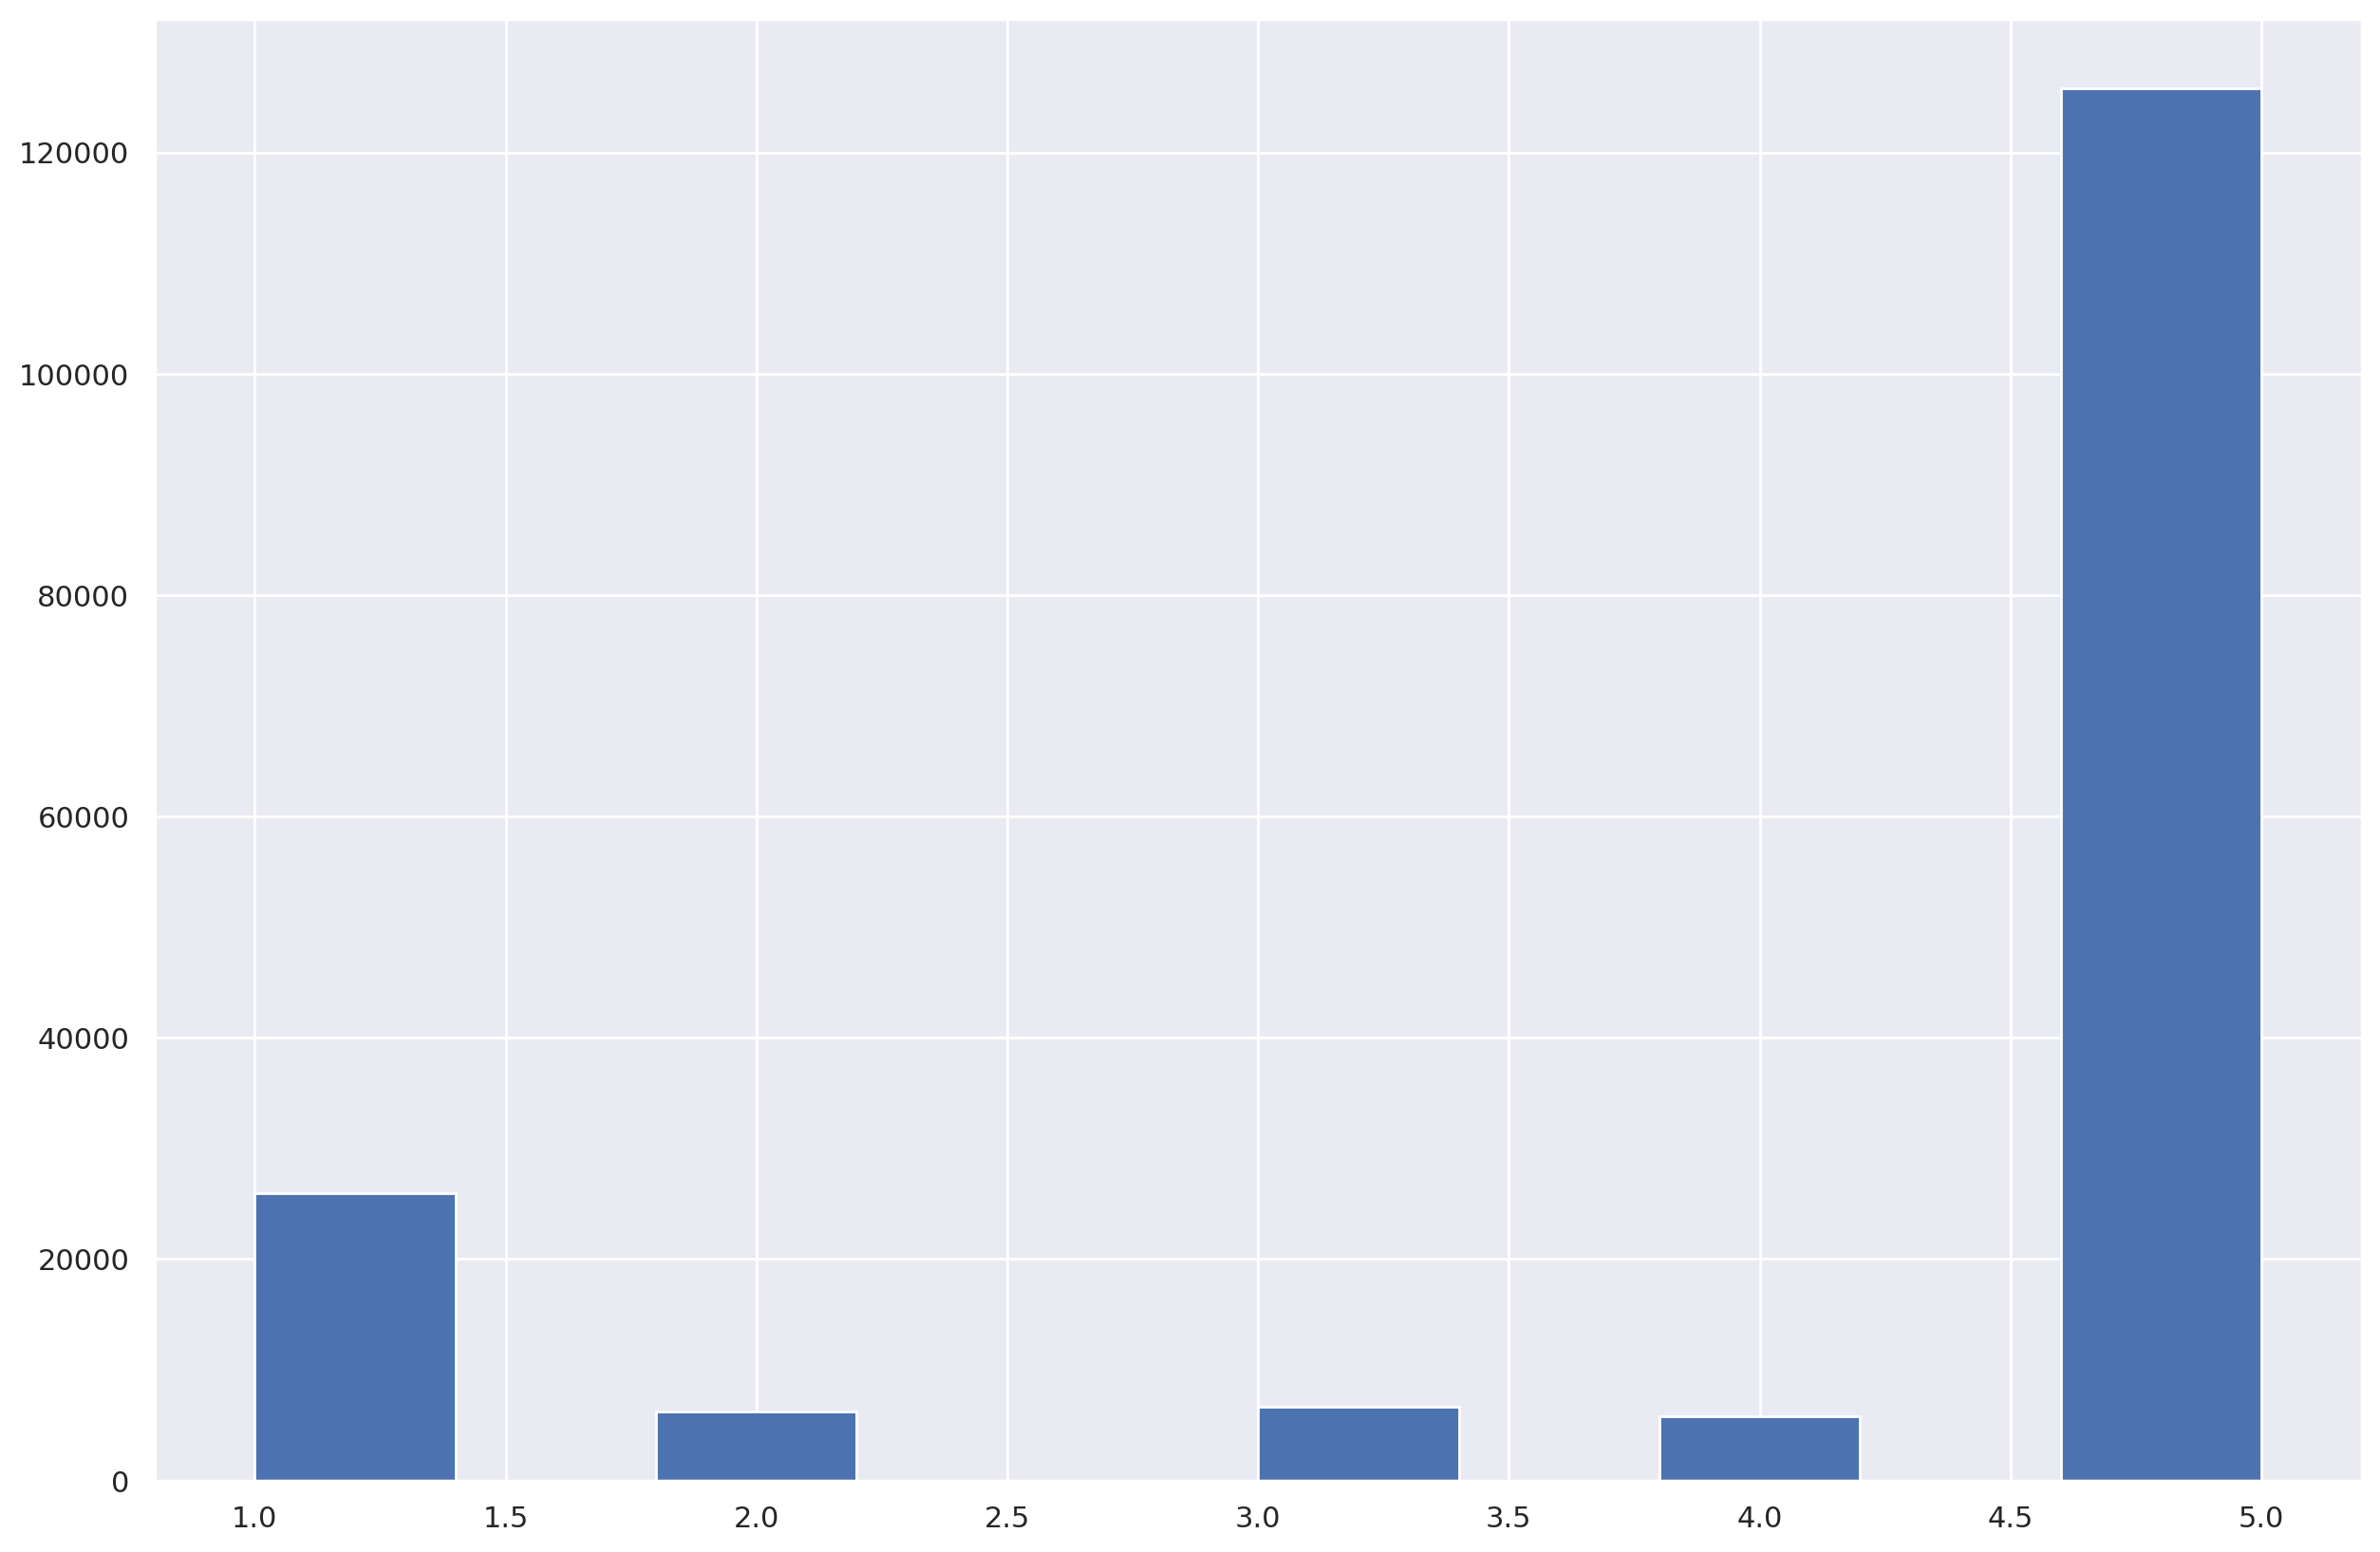

In [81]:
plt.hist(df_alfagiftrev['score'])
plt.show()

In [82]:
#DATA PREPROCESSING
# Lower casing

# Change the reviews type to string
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_alfagiftrev['content'][22442])

sangat membantu dalam melakukan pembelanjaan onlinee🥰🥰


In [83]:
#Lowercase all reviews to see the difference
df_alfagiftrev['content']= df_alfagiftrev['content'].apply(lambda x: x.lower())
print(df_alfagiftrev['content'][22442])

sangat membantu dalam melakukan pembelanjaan onlinee🥰🥰


In [84]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [85]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_alfagiftrev['wordCount'] = [len(review.split()) for review in df_alfagiftrev['content']]

df_alfagiftrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_alfagiftrev['content']]

df_alfagiftrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_alfagiftrev['content']]

In [86]:
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,parah banget alfagift pengembalian dana nya super lama ! padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin !!,1,0.651042,0.666667,30,0,3
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko (swalayan).. belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg ...,5,1.000000,0.300000,58,0,13
2,sklrg aplikasi jauh lbh baik. tp barang yg dikirim tolong di cek. 2x kena zonk. sosis dan susu milku.,5,0.000000,0.000000,19,0,4
3,belakangan sangat lambat pengirimannya... saya pesan 7 jam baru diantar pesan 10.27 diterima 17.30 (ds galaxy) yang tadinya mau dipakai utk nyuci akhirnya batal nyuci. klik indomaret lebih cepet t...,2,0.000000,0.000000,31,0,8
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0.000000,0.000000,16,0,0
...,...,...,...,...,...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000000,0.000000,8,0,6
170485,alfamart belanja puas harga pas....,5,0.000000,0.000000,5,0,4
170486,ameijing,5,0.000000,0.000000,1,0,0
170487,keren banget .....,5,0.000000,0.000000,3,0,5


In [87]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [88]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

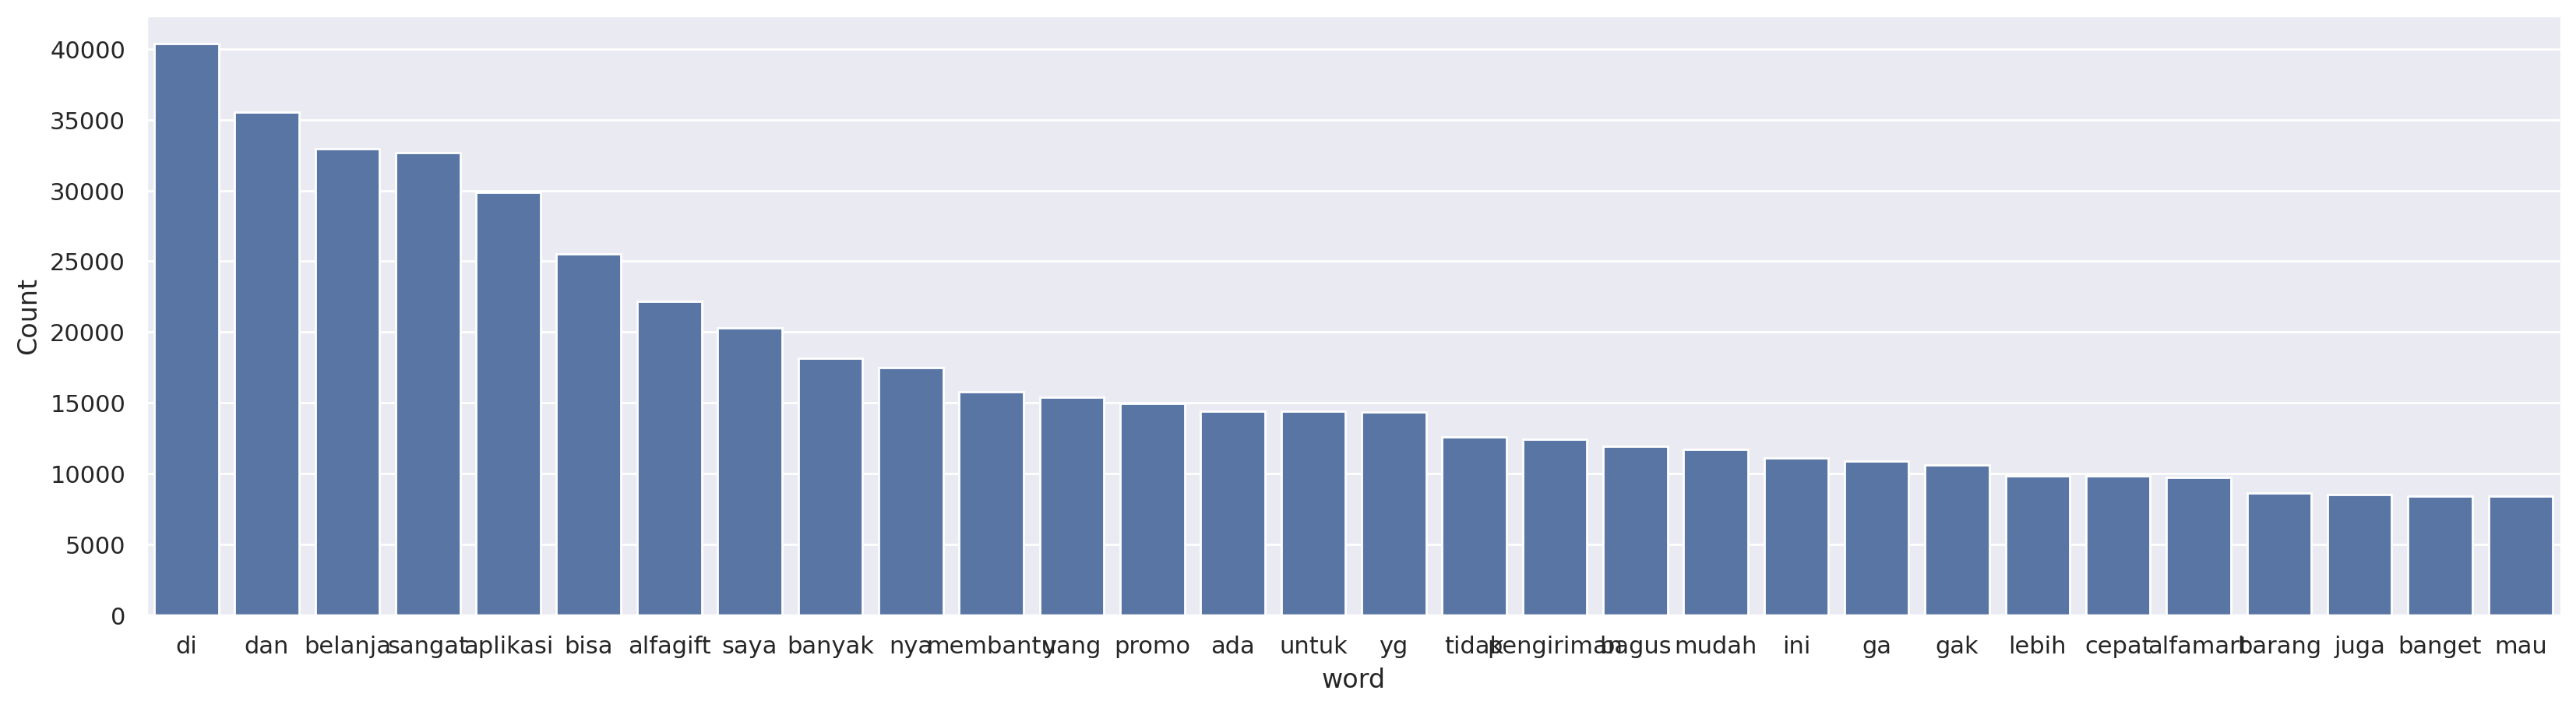

In [89]:
freq_words(df_alfagiftrev['content'])

In [90]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_alfagiftrev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)
    return expe.sub(r'',s)

for y in df_alfagiftrev['content']:
    #print(str(extract_emojis(y)))
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)
df_alfagiftrev['content'].apply(extract_emojis)

True
['[]', "['🙏', '🙏', '🙏']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😂']", "['😌']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👎', '👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🙏']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😂']", '[]', '[]', '[]', "['😡']", '[]', '[]', '[]', "['😍', '🥰', '🥰', '🤗', '🤭', '👍', '👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '👍']", "['👍', '👍', '👍', '👍', '👍']", '[]', '[]', '[]', '[]', '[]', '[]', "['🙏']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😡', '😡']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '

,content
0,[]
1,"[🙏, 🙏, 🙏]"
2,[]
3,[]
4,[]
...,...
170484,[]
170485,[]
170486,[]
170487,[]


In [91]:
df_alfagiftrev.loc[:,["content", "score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,parah banget alfagift pengembalian dana nya super lama ! padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin !!,1,0.651042,0.666667,30,0,3
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko (swalayan).. belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg ...,5,1.000000,0.300000,58,0,13
2,sklrg aplikasi jauh lbh baik. tp barang yg dikirim tolong di cek. 2x kena zonk. sosis dan susu milku.,5,0.000000,0.000000,19,0,4
3,belakangan sangat lambat pengirimannya... saya pesan 7 jam baru diantar pesan 10.27 diterima 17.30 (ds galaxy) yang tadinya mau dipakai utk nyuci akhirnya batal nyuci. klik indomaret lebih cepet t...,2,0.000000,0.000000,31,0,8
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0.000000,0.000000,16,0,0
...,...,...,...,...,...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000000,0.000000,8,0,6
170485,alfamart belanja puas harga pas....,5,0.000000,0.000000,5,0,4
170486,ameijing,5,0.000000,0.000000,1,0,0
170487,keren banget .....,5,0.000000,0.000000,3,0,5


In [92]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_alfagiftrev['sentiment_rating'] = df_alfagiftrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [93]:
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,parah banget alfagift pengembalian dana nya super lama ! padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin !!,1,0.651042,0.666667,Negative
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko (swalayan).. belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg ...,5,1.000000,0.300000,Positive
2,sklrg aplikasi jauh lbh baik. tp barang yg dikirim tolong di cek. 2x kena zonk. sosis dan susu milku.,5,0.000000,0.000000,Positive
3,belakangan sangat lambat pengirimannya... saya pesan 7 jam baru diantar pesan 10.27 diterima 17.30 (ds galaxy) yang tadinya mau dipakai utk nyuci akhirnya batal nyuci. klik indomaret lebih cepet t...,2,0.000000,0.000000,Negative
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0.000000,0.000000,Positive
...,...,...,...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000000,0.000000,Positive
170485,alfamart belanja puas harga pas....,5,0.000000,0.000000,Positive
170486,ameijing,5,0.000000,0.000000,Positive
170487,keren banget .....,5,0.000000,0.000000,Positive


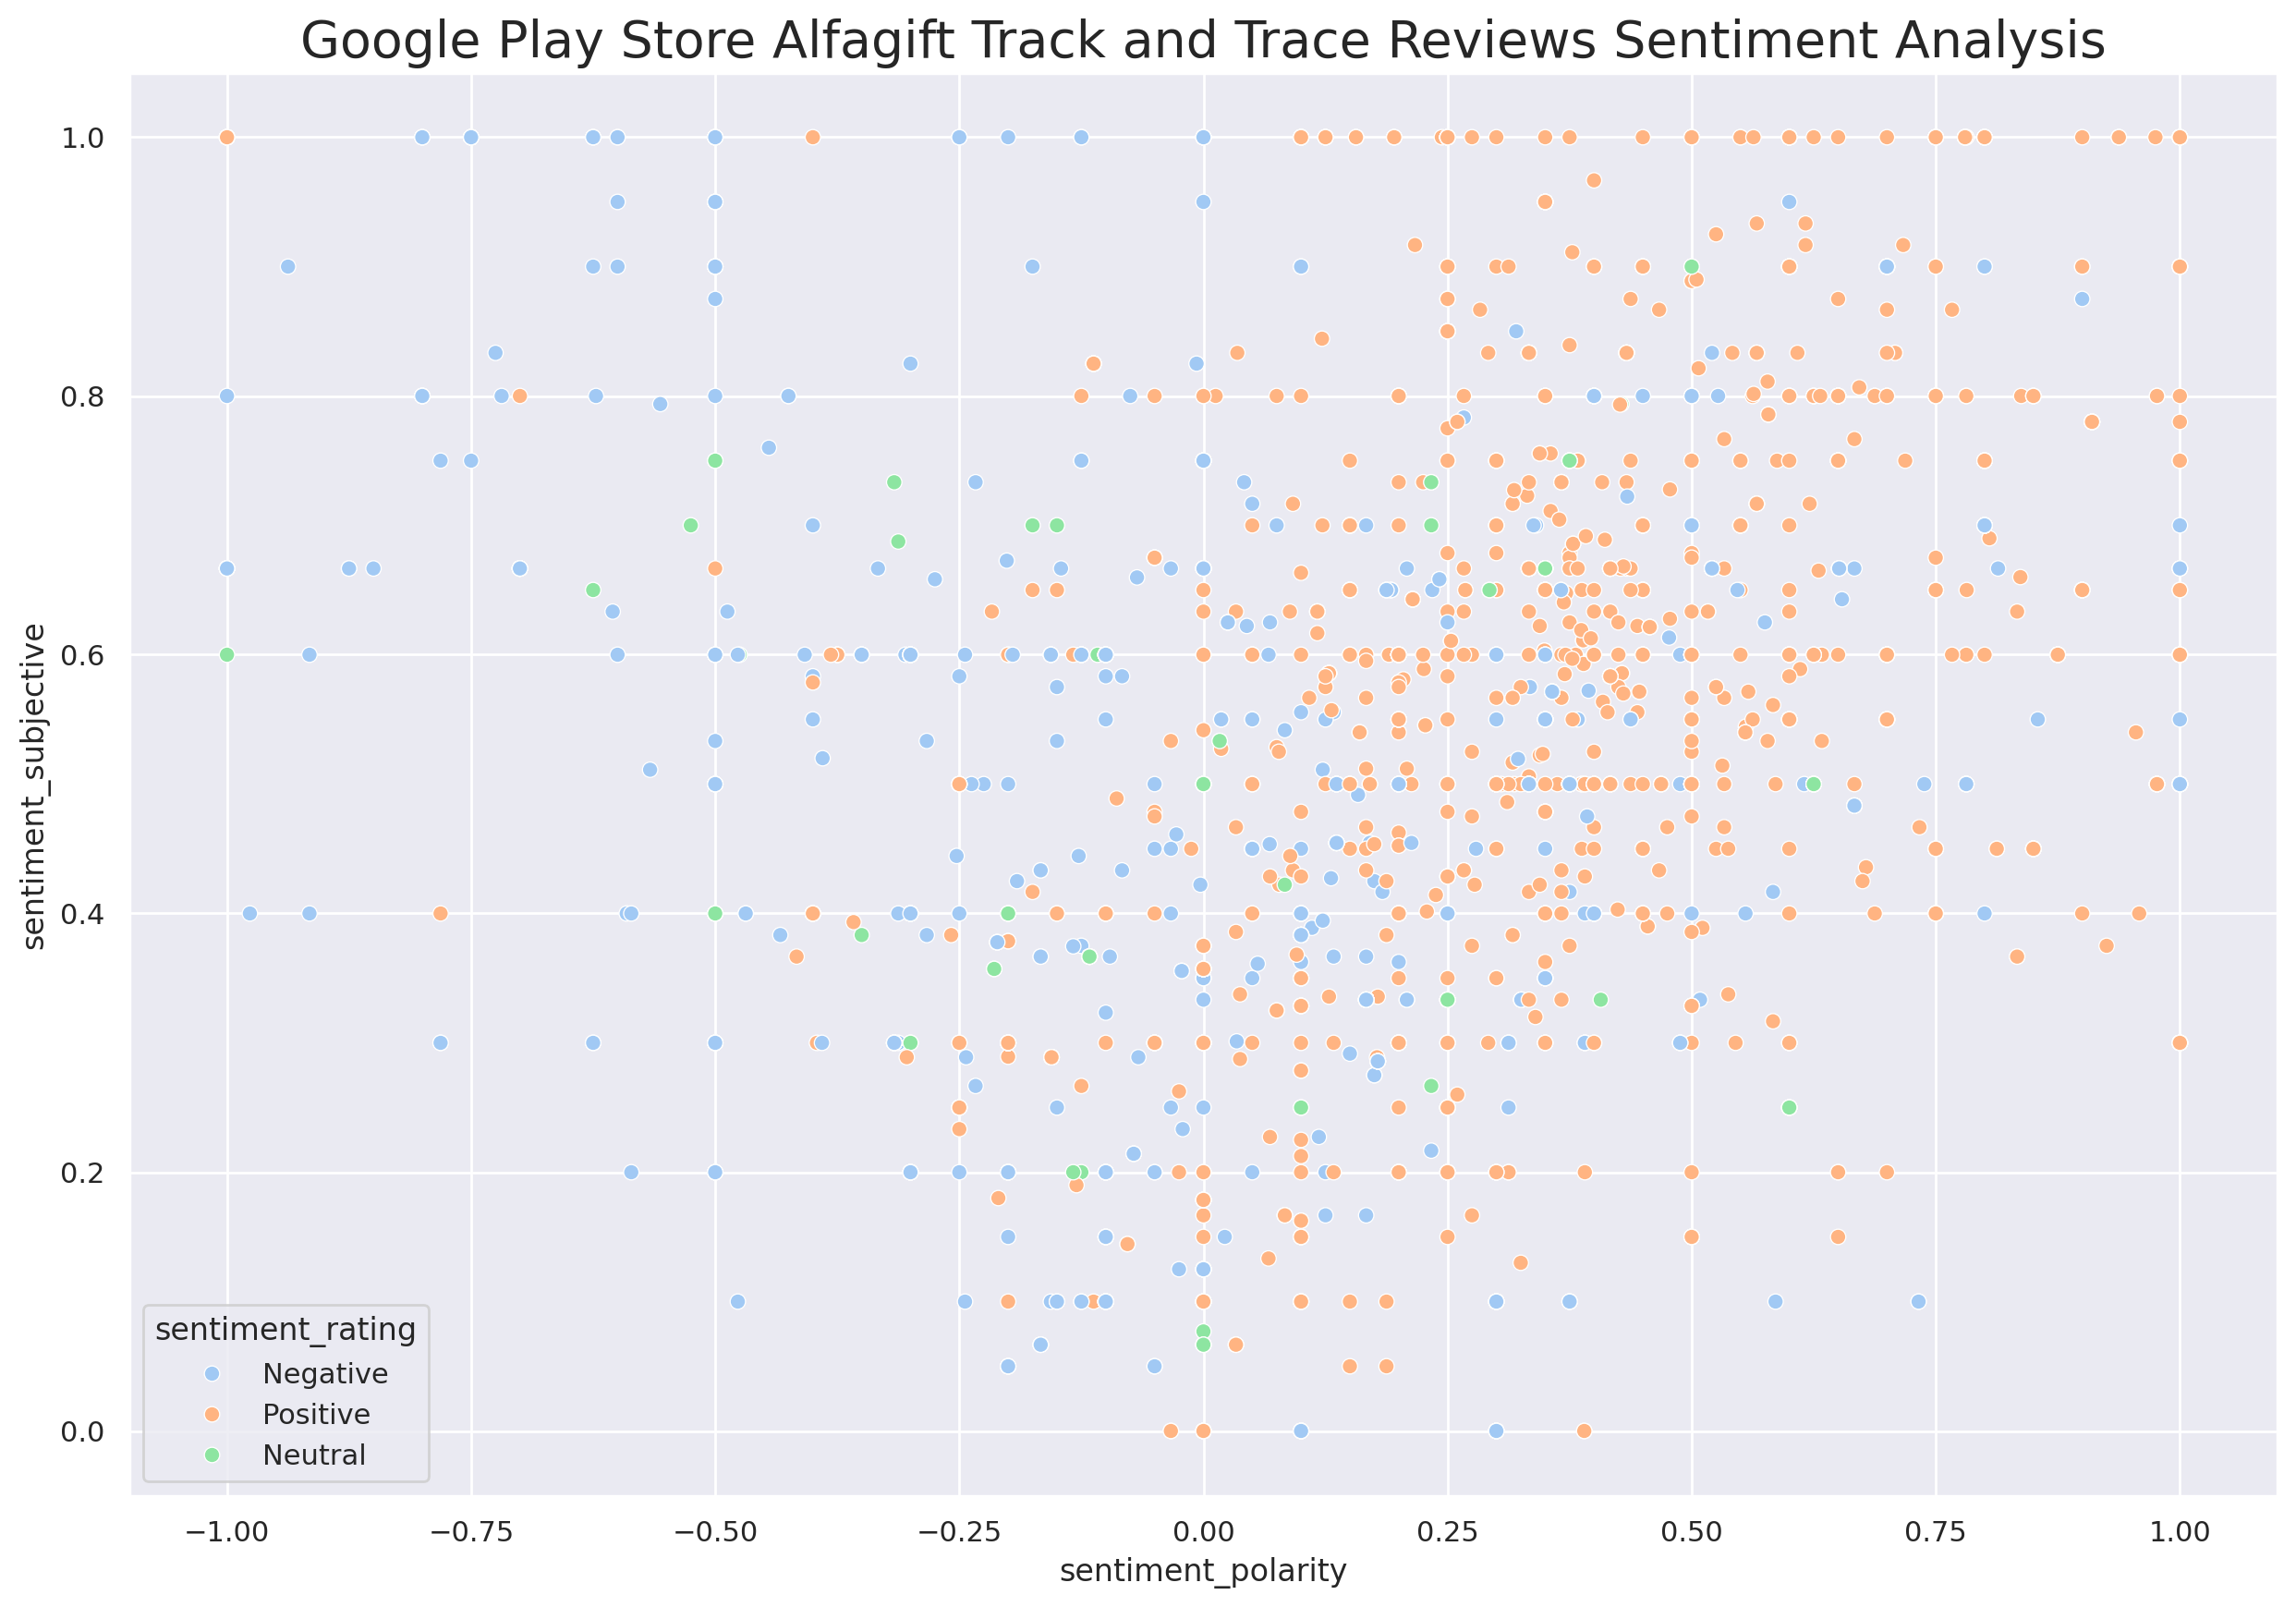

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_alfagiftrev['sentiment_polarity'], y=df_alfagiftrev['sentiment_subjective'],
                hue = df_alfagiftrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Alfagift Track and Trace Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [95]:
#Print the extracted emojis review column (content) before stopwords
df_alfagiftrev.to_csv(r'df_alfagiftrev_before_stopwords_sentiment_rating.csv', index = False)

In [96]:
# remove punctuation
# Ensure 'content' is string type before applying string methods
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)
df_alfagiftrev['content'] = df_alfagiftrev['content'].str.replace(r'[.,";\'?\!(\-/):)]', '', regex=True)

# ATAU, jika kamu ingin menghilangkan SEMUA tanda baca (semua punctuation):
# df_alfagiftrev['content'] = df_alfagiftrev['content'].str.replace(r'[^\w\s]', '', regex=True)

print(df_alfagiftrev['content'].head())

0                          parah banget alfagift pengembalian dana nya super lama  padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin 
1    aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...
2                                                                                                          sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku
3     belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya batal nyuci klik indomaret lebih cepet tepat waktu
4                                                                                                                     sangat membantu bagi yg mageran maaf min mau tanya akun yg uda

In [97]:
df_alfagiftrev_stopwords = df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [98]:
import re

# 1. Pastikan kamus singkatan sudah didefinisikan
kamus_singkatan = {
    'aj': 'saja', 'aja': 'saja', 'ak': 'aku', 'aq': 'aku', 'atas': 'atas',
    'bagus': 'bagus', 'bagusss': 'bagus', 'bbrp': 'beberapa', 'bbrpa': 'beberapa', 'bener': 'benar',
    'bg': 'abang', 'bgs': 'bagus', 'bgt': 'banget', 'bgts': 'banget', 'bgtt': 'banget', 'bgttt': 'banget', 'bngt': 'banget', 'bangettt': 'banget',
    'bgtu': 'begitu', 'bgitu': 'begitu', 'bikin': 'membuat', 'bkn': 'bukan',
    'blg': 'bilang', 'blh': 'boleh', 'blk': 'balik', 'blj': 'belanja', 'blkng': 'belakang',
    'blm': 'belum', 'bln': 'bulan', 'blnj': 'belanja', 'blnjn': 'belanjaan',
    'bls': 'balas', 'bnyk': 'banyak', 'bnykk': 'banyak', 'bnykn': 'kebanyakan',
    'bpk': 'bapak', 'br': 'baru', 'brg': 'barang', 'brgny': 'barangnya',
    'brng': 'barang', 'brp': 'berapa', 'bs': 'bisa', 'bsk': 'besok', 'bt': 'buat',
    'bth': 'butuh', 'btl': 'betul', 'btw': 'ngomong-ngomong', 'bukan': 'bukan',
    'bw': 'bawa', 'bwh': 'bawah', 'bwt': 'buat', 'byk': 'banyak', 'byr': 'bayar',
    'cb': 'coba', 'cctv': 'cctv', 'cepet': 'cepat', 'cepattt': 'cepat', 'cm': 'cuma', 'cmn': 'cuman',
    'cpet': 'cepat', 'cpt': 'cepat', 'cr': 'cara', 'cs': 'customer service',
    'd': 'di', 'deket': 'dekat', 'dftr': 'daftar', 'dg': 'dengan', 'dgn': 'dengan',
    'dh': 'sudah', 'dkk': 'dan kawan-kawan', 'dkt': 'dekat', 'dl': 'dulu', 'dll': 'dan lain lain',
    'dlm': 'dalam', 'dlu': 'dulu', 'dm': 'direct message', 'dmn': 'dimana',
    'dn': 'dan', 'dng': 'dengan', 'dngn': 'dengan', 'dpn': 'depan', 'dpt': 'dapat',
    'dr': 'dari', 'drpd': 'daripada', 'dsb': 'dan sebagainya', 'dst': 'dan seterusnya',
    'dtg': 'datang', 'dtng': 'datang', 'dy': 'dia',
    'ga': 'tidak', 'gak': 'tidak', 'gbr': 'gambar', 'gimana': 'bagaimana',
    'gini': 'begini', 'gitu': 'begitu', 'gk': 'tidak', 'gmn': 'bagaimana',
    'gt': 'begitu', 'gto': 'begitu', 'gtu': 'begitu', 'gw': 'saya', 'gx': 'tidak',
    'hb': 'habis', 'hp': 'handphone', 'hrg': 'harga', 'hrp': 'harap', 'hrs': 'harus',
    'ig': 'instagram',
    'jd': 'jadi', 'jdi': 'jadi', 'jg': 'juga', 'jgn': 'jangan', 'jln': 'jalan',
    'jm': 'jam', 'jml': 'jumlah', 'josss': 'jos', 'jsm': 'jumat sabtu minggu', 'jwb': 'jawab',
    'k': 'ke', 'ka': 'kakak', 'kak': 'kakak', 'kalo': 'kalau', 'kbr': 'kabar',
    'kcpt': 'kecepatan', 'kdg': 'kadang', 'kek': 'seperti', 'kerennn': 'keren', 'kgk': 'tidak',
    'kk': 'kakak', 'kl': 'kalau', 'klo': 'kalau', 'klw': 'kalau', 'km': 'kamu', 'kmn': 'kemana',
    'kn': 'kan', 'knp': 'kenapa', 'kpd': 'kepada', 'kpn': 'kapan', 'krg': 'kurang',
    'krm': 'kirim', 'krn': 'karena', 'krna': 'karena', 'ksh': 'kasih', 'kt': 'kita', 'kyk': 'seperti',
    'lagiii': 'lagi', 'lamaaa': 'lama', 'lbh': 'lebih', 'lg': 'lagi', 'lgi': 'lagi', 'lgsg': 'langsung',
    'lm': 'lama', 'lma': 'lama', 'lmbt': 'lambat', 'lnjt': 'lanjut', 'lwt': 'lewat',
    'mantaaap': 'mantap', 'mantappp': 'mantap', 'mantulll': 'mantul', 'mhl': 'mahal',
    'mk': 'maka', 'mks': 'terima kasih', 'mksd': 'maksud', 'mlh': 'malah',
    'mlm': 'malam', 'mls': 'malas', 'mn': 'mana', 'mnrt': 'menurut', 'mrk': 'mereka',
    'msh': 'masih', 'msk': 'masuk', 'msn': 'mesin', 'mt': 'mati', 'mw': 'mau',
    'n': 'dan', 'ndak': 'tidak', 'ng': 'meng', 'ngga': 'tidak', 'nggak': 'tidak', 'nggk': 'tidak', 'ngk': 'tidak',
    'nmr': 'nomor', 'nnt': 'nanti', 'nnti': 'nanti', 'ntar': 'nanti', 'ntr': 'nanti',
    'ny': 'nya', 'nya': 'nya',
    'ongkir': 'ongkos kirim',
    'paraaaah': 'parah', 'pd': 'pada', 'pdhl': 'padahal', 'pke': 'pakai', 'pkt': 'paket',
    'plg': 'paling', 'plng': 'paling', 'ppn': 'pajak', 'promonyaaa': 'promonya', 'prt': 'perut',
    'psn': 'pesan', 'pst': 'pasti', 'pt': 'pt',
    'rb': 'ribu', 'rmh': 'rumah', 'rp': 'rupiah', 'rt': 'rt', 'rw': 'rw',
    'sbg': 'sebagai', 'sdg': 'sedang', 'sdh': 'sudah', 'sdkt': 'sedikit',
    'sgt': 'sangat', 'skg': 'sekarang', 'skr': 'sekarang', 'sklrg': 'sekarang', 'skrg': 'sekarang', 'skrng': 'sekarang',
    'skt': 'sakit', 'slh': 'salah', 'sll': 'selalu', 'sm': 'sama', 'sma': 'sama', 'smg': 'semoga',
    'smp': 'sampai', 'sngt': 'sangat', 'spt': 'seperti', 'stgh': 'setengah', 'stlh': 'setelah',
    'sy': 'saya', 'sya': 'saya',
    'tdk': 'tidak', 'tf': 'transfer', 'tgl': 'tanggal', 'thd': 'terhadap', 'thdp': 'terhadap',
    'thks': 'terima kasih', 'thx': 'terima kasih', 'tk': 'toko', 'tks': 'terima kasih', 'tlg': 'tolong',
    'tlp': 'telepon', 'tmp': 'tempat', 'tp': 'tapi', 'trs': 'terus', 'tsb': 'tersebut',
    'tpi': 'tapi', 'ttg': 'tentang', 'ttp': 'tetap', 'tu': 'itu', 'tx': 'terima kasih',
    'udh': 'sudah', 'utk': 'untuk',
    'wkt': 'waktu', 'wktu': 'waktu',
    'y': 'ya', 'ya': 'ya', 'yaaa': 'ya', 'yah': 'ya', 'yg': 'yang', 'yng': 'yang'
}

# 2. Fungsi normalisasi
def normalize_text(text):
    # Ensure text is a string before splitting
    text = str(text)
    # Memisahkan string berdasarkan tanda baca/spasi (\W+)
    words = re.split(r'(\W+)', text)

    normalized_words = []
    for word in words:
        lower_word = word.lower()
        if lower_word in kamus_singkatan:
            kata_baku = kamus_singkatan[lower_word]

            # Pertahankan format kapitalisasi
            if word.istitle():
                normalized_words.append(kata_baku.title())
            elif word.isupper():
                normalized_words.append(kata_baku.upper())
            else:
                normalized_words.append(kata_baku)
        else:
            normalized_words.append(word)

    return ''.join(normalized_words)

# 3. Buat kolom baru langsung di dataframe Anda
# Apply to the 'content' column of df_alfagiftrev, not df_alfagiftrev_stopwords
df_alfagiftrev_stopwords['spelled_correction'] = df_alfagiftrev_stopwords['content'].apply(normalize_text)

# (Opsional) Cek hasilnya
print(df_alfagiftrev_stopwords[['content', 'spelled_correction']].head())

                                                                                                                                                                                                   content  \
0                        parah banget alfagift pengembalian dana nya super lama  padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin    
1  aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...   
2                                                                                                        sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku   
3   belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya batal nyuci klik indomar

In [99]:
import nltk
from nltk.corpus import stopwords

# Download Indonesian stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop = stopwords.words('english') + ["someone","still","would","need", "gak", "ga", "yg", "aja", "nya", "gk" ,",", "."]
stop.extend(stopwords.words('indonesian'))
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [100]:
print(len(stop))

968


In [101]:
# Exclude stopwords
df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['spelled_correction'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
df_alfagiftrev_stopwords.loc[:,["content","tweet_without_stopwords"]]

,content,tweet_without_stopwords
0,parah banget alfagift pengembalian dana nya super lama padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin,parah banget alfagift pengembalian dana super cancel krna pengiriman akibat banjir tpi pengembalian dana udah 4 dibalikin
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...,aplikasi bagus menurutku berguna memudahkan berbelanja cepat toko swalayan belanja dirumah mudah tinggal klik barang sampe rumah aman cepat pokoknya amanah pelayanan bagus emang best alfamart teri...
2,sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku,aplikasi barang dikirim tolong cek 2x kena zonk sosis susu milku
3,belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya batal nyuci klik indomaret lebih cepet tepat waktu,lambat pengirimannya pesan 7 jam diantar pesan 1027 diterima 1730 ds galaxy dipakai nyuci batal nyuci klik indomaret cepat
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,membantu mageran maaf min akun udah keblokir blik
...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampirmampirdan mampir lagi,terobosannya memudahkan pelanggan mampirmampirdan mampir
170485,alfamart belanja puas harga pas,alfamart belanja puas harga pas
170486,ameijing,ameijing
170487,keren banget,keren banget


In [102]:
# pat = r'\b(?:{})\b'.format('|'.join(stop))
# The lines below are removed as the stopword removal is already handled by cell 37f3557d
# df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['content'].str.replace(pat, '')
# df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ')
print(df_alfagiftrev_stopwords)

                                                                                                                                                                                                        content  \
0                             parah banget alfagift pengembalian dana nya super lama  padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin    
1       aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...   
2                                                                                                             sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku   
3        belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya

In [103]:
df_alfagiftrev_stopwords.loc[:,["content","tweet_without_stopwords"]]

,content,tweet_without_stopwords
0,parah banget alfagift pengembalian dana nya super lama padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin,parah banget alfagift pengembalian dana super cancel krna pengiriman akibat banjir tpi pengembalian dana udah 4 dibalikin
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...,aplikasi bagus menurutku berguna memudahkan berbelanja cepat toko swalayan belanja dirumah mudah tinggal klik barang sampe rumah aman cepat pokoknya amanah pelayanan bagus emang best alfamart teri...
2,sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku,aplikasi barang dikirim tolong cek 2x kena zonk sosis susu milku
3,belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya batal nyuci klik indomaret lebih cepet tepat waktu,lambat pengirimannya pesan 7 jam diantar pesan 1027 diterima 1730 ds galaxy dipakai nyuci batal nyuci klik indomaret cepat
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,membantu mageran maaf min akun udah keblokir blik
...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampirmampirdan mampir lagi,terobosannya memudahkan pelanggan mampirmampirdan mampir
170485,alfamart belanja puas harga pas,alfamart belanja puas harga pas
170486,ameijing,ameijing
170487,keren banget,keren banget


In [104]:
#Save into csv after applying stopwords
df_alfagiftrev_stopwords.to_csv(r'df_alfagiftrev_after_stopwords_sentiment_rating2.csv', index = False)

In [105]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_alfagiftrev_stopwords['wordCount'] = [len(review.split()) for review in df_alfagiftrev_stopwords['content']]
df_alfagiftrev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_alfagiftrev_stopwords['tweet_without_stopwords']]


In [106]:
df_alfagiftrev_stopwords.loc[:,["content","score","sentiment_polarity", "sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_polarity,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,parah banget alfagift pengembalian dana nya super lama padahal jelas di cancel krna ga ada pengiriman akibat banjir tpi pengembalian dana nya udah 4 hari masih belum dibalikin,1,0.651042,Negative,28,parah banget alfagift pengembalian dana super cancel krna pengiriman akibat banjir tpi pengembalian dana udah 4 dibalikin,17
1,aplikasi ini sangat bagus menurutku berguna sekali memudahkan saya berbelanja dengan cepat tanpa harus ke tempat toko swalayan belanja dirumah jadi mudah tinggal klik barang sampe ke rumah dg aman...,5,1.000000,Positive,57,aplikasi bagus menurutku berguna memudahkan berbelanja cepat toko swalayan belanja dirumah mudah tinggal klik barang sampe rumah aman cepat pokoknya amanah pelayanan bagus emang best alfamart teri...,34
2,sklrg aplikasi jauh lbh baik tp barang yg dikirim tolong di cek 2x kena zonk sosis dan susu milku,5,0.000000,Positive,19,aplikasi barang dikirim tolong cek 2x kena zonk sosis susu milku,11
3,belakangan sangat lambat pengirimannya saya pesan 7 jam baru diantar pesan 1027 diterima 1730 ds galaxy yang tadinya mau dipakai utk nyuci akhirnya batal nyuci klik indomaret lebih cepet tepat waktu,2,0.000000,Negative,31,lambat pengirimannya pesan 7 jam diantar pesan 1027 diterima 1730 ds galaxy dipakai nyuci batal nyuci klik indomaret cepat,19
4,sangat membantu bagi yg mageran maaf min mau tanya akun yg udah keblokir bisa blik lgi,5,0.000000,Positive,16,membantu mageran maaf min akun udah keblokir blik,8
...,...,...,...,...,...,...,...
170484,terobosannya memudahkan pelanggan untuk selalu mampirmampirdan mampir lagi,5,0.000000,Positive,8,terobosannya memudahkan pelanggan mampirmampirdan mampir,5
170485,alfamart belanja puas harga pas,5,0.000000,Positive,5,alfamart belanja puas harga pas,5
170486,ameijing,5,0.000000,Positive,1,ameijing,1
170487,keren banget,5,0.000000,Positive,2,keren banget,2


In [107]:
# function to plot most frequent terms
def freq_words(x, terms = 25):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top `terms` most frequent words, which controls the number of words on the x-axis
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(8,5))
  ax = sns.barplot(data=d, x= "word", y = "count", hue="word", legend=False, palette="viridis")
  ax.set(ylabel = 'Count')
  plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

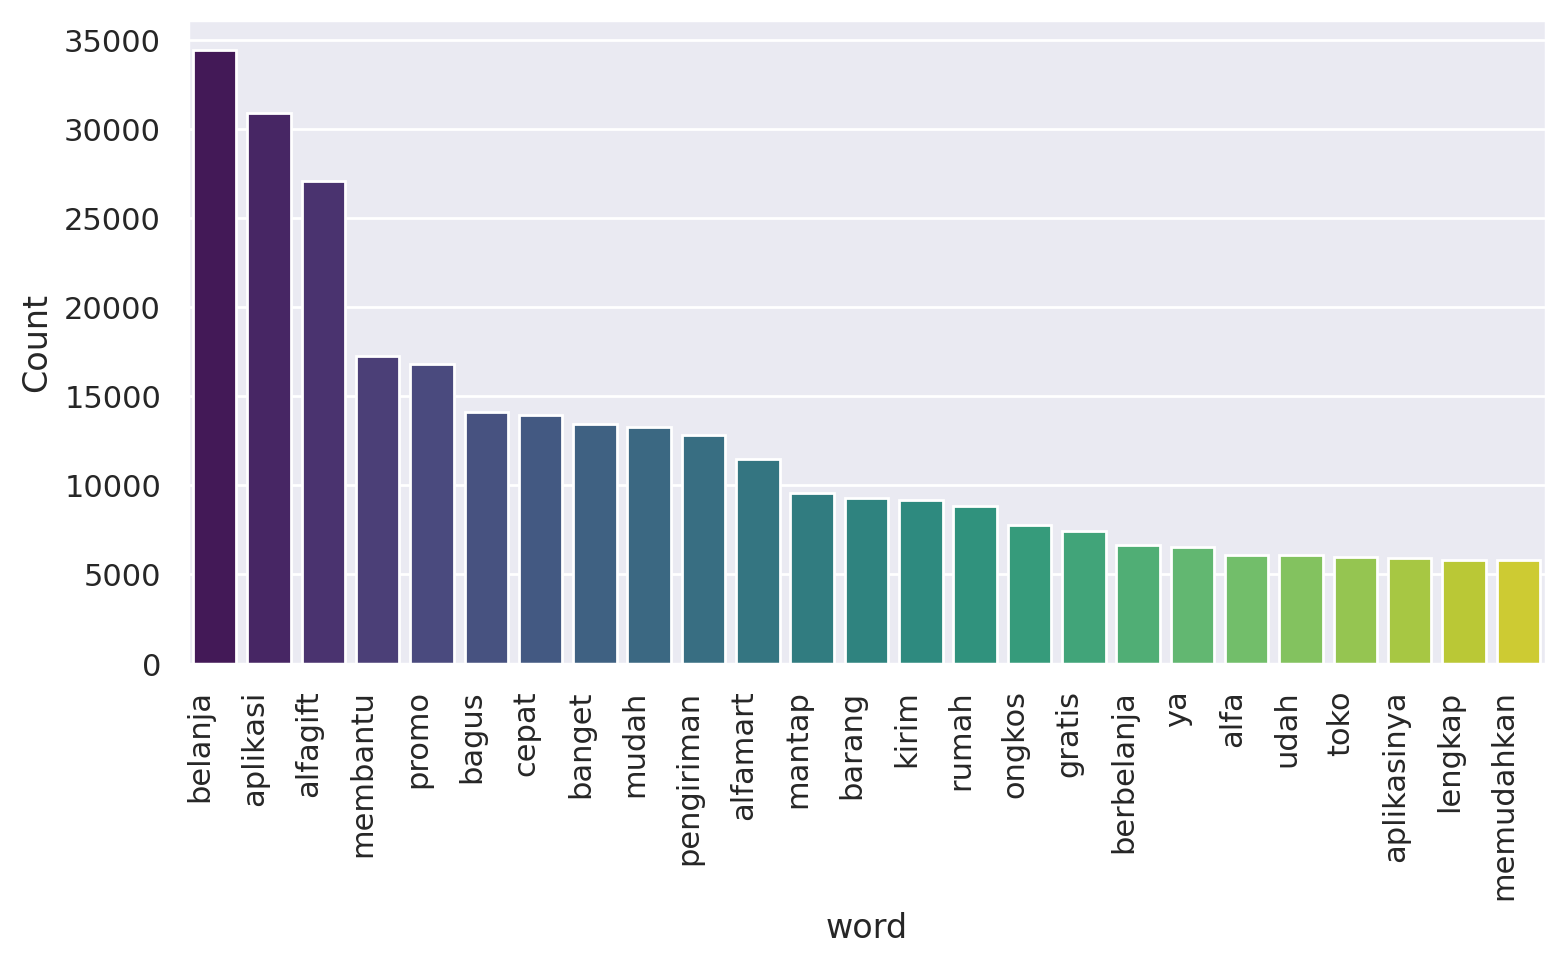

In [108]:
freq_words(df_alfagiftrev_stopwords['tweet_without_stopwords'])

In [109]:
newStopWords = ["'",".",",", "someone","still","would","need",""]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [110]:
#Stemming

#Stemming function chops off the end of the word
#and transform the word into its root form.
#All suffixes like -s, -es, -ed, -ing are removed.

def stemming(x):
    st = PorterStemmer()
    if x is not None:
       for word in x.split():
           st.stem(word)

df_alfagiftrev_stopwords['tweet_without_stopwords'].apply(lambda x:stemming(x))
print(df_alfagiftrev_stopwords['tweet_without_stopwords'][2109])

promo harga murah


In [111]:
!pip install Sastrawi

In [ ]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Inisialisasi Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Buat fungsi stemming untuk bahasa Indonesia
def stemming_indonesia(x):
    # Cek apakah nilai x tidak kosong/NaN
    if pd.notnull(x):
        # Sastrawi stemmer bisa langsung memproses satu kalimat utuh
        # tanpa perlu kita split() manual menggunakan perulangan (for word in x.split())
        return stemmer.stem(str(x))
    return x

# 3. Terapkan fungsi ke dataframe dan buat kolom baru (opsional)
# disarankan membuat kolom baru agar teks sebelum stemming tidak hilang
df_alfagiftrev_stopwords['tweet_without_stopwords'].apply(stemming_indonesia)

# 4. Cek hasilnya
print(df_alfagiftrev_stopwords['tweet_without_stopwords'][2109])

In [ ]:
#DROP NA
df_alfagiftrev_stopwords.dropna(inplace=True)
df_alfagiftrev_stopwords.info()

In [ ]:
df_alfagiftrev_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]